# K-Means con Palmer Penguins (autocontenido)

Este notebook muestra un flujo completo de **clustering con K-Means** usando el dataset **Palmer Penguins**:

- Carga robusta del dataset (`palmerpenguins` con *fallback* a `seaborn`).
- Preprocesamiento (imputación + escalado).
- Selección de **k** mediante **Elbow (inertia)** y **Silueta**.
- Entrenamiento del modelo final.
- Visualización con **PCA** (2D) para inspección.
- “Predicción” de **especie** para datos nuevos mediante un mapeo **cluster → especie** por mayoría (*post-hoc*).

> Nota: **K-Means es no supervisado**. La “predicción de especie” aquí es una aproximación práctica (baseline) que asigna a cada cluster la especie mayoritaria observada en los datos etiquetados.


In [25]:
# =========================
# Imports y configuración
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

plt.rcParams["figure.dpi"] = 120


In [26]:
# =========================
# 1) Carga del dataset
# =========================

df = pd.read_csv('../data/penguins.csv')
print("Shape:", df.shape)
df.head()


Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


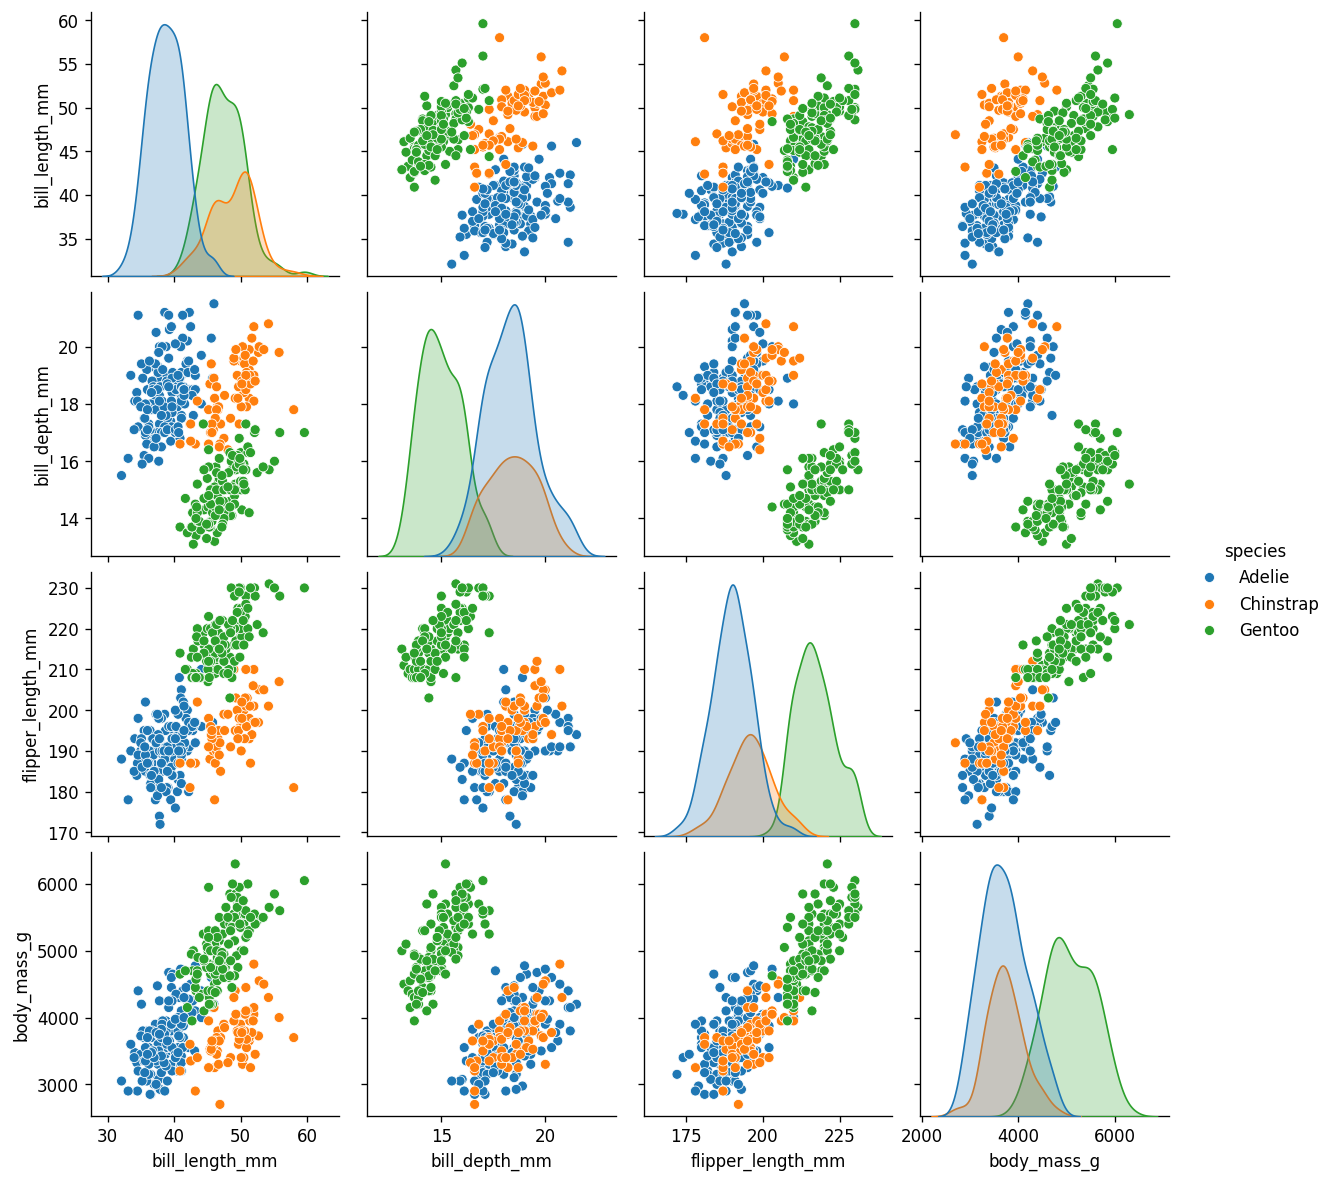

In [27]:
pairplot_figure = sns.pairplot(df, hue="species")

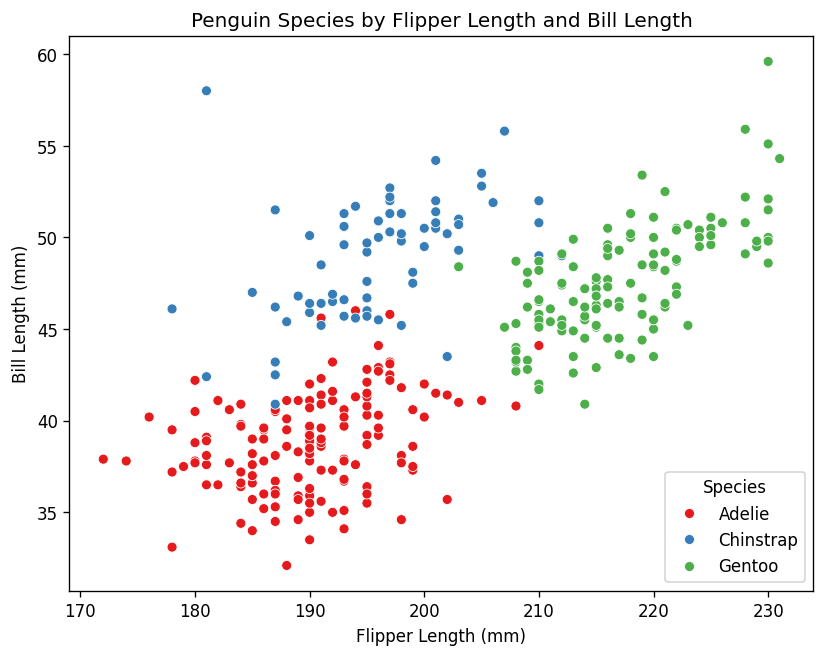

In [29]:
# Graficar los clusters usando matplotlib Flipper length vs. bill length
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='flipper_length_mm', y='bill_length_mm', hue='species', palette='Set1')
plt.title('Penguin Species by Flipper Length and Bill Length')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Bill Length (mm)')
plt.legend(title='Species')
plt.show()

## 2) Selección de variables y preprocesamiento

Usaremos variables numéricas típicas del dataset:

- `bill_length_mm`
- `bill_depth_mm`
- `flipper_length_mm`
- `body_mass_g`

Como K-Means usa distancias Euclidianas, el **escalado** es crítico (si no, variables con mayor rango dominan).  
También imputaremos valores faltantes con la **mediana**.


In [16]:
feature_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
target_col = "species"  # se usa sólo para el mapeo post-hoc cluster->especie

work = df[feature_cols + [target_col]].copy()

# Pipeline de preprocesamiento
preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_raw = work[feature_cols]
y = work[target_col]

X = preprocess.fit_transform(X_raw)
X.shape


(344, 4)

## 3) Determinar k con Elbow y Silueta

- **Elbow**: usa `inertia_` (SSE intra-cluster). Buscamos un “codo”: a partir de cierto k, la mejora marginal cae.
- **Silueta**: mide separación vs cohesión (rango -1 a 1). Mayor es mejor. Requiere k ≥ 2.


Mejor k según silhouette: 2 (score=0.5307)


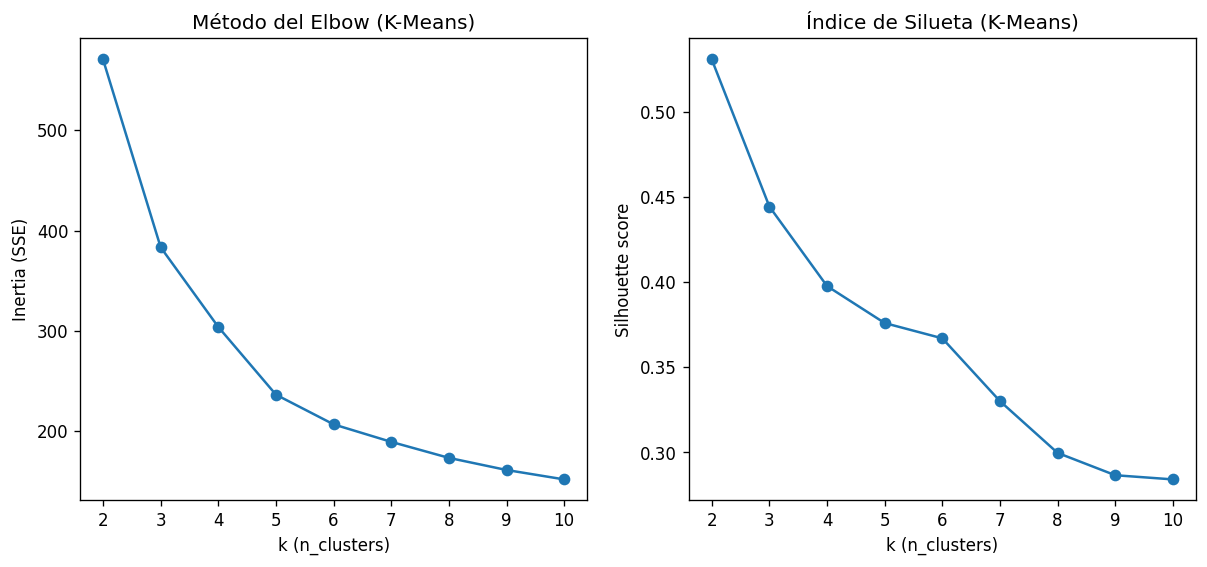

In [17]:
k_values = range(2, 11)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

best_k_sil = list(k_values)[int(np.argmax(sil_scores))]
print(f"Mejor k según silhouette: {best_k_sil} (score={max(sil_scores):.4f})")

# Gráficos
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("k (n_clusters)")
plt.ylabel("Inertia (SSE)")
plt.title("Método del Elbow (K-Means)")

plt.subplot(1, 2, 2)
plt.plot(list(k_values), sil_scores, marker="o")
plt.xlabel("k (n_clusters)")
plt.ylabel("Silhouette score")
plt.title("Índice de Silueta (K-Means)")
plt.show()


## 4) Entrenar el K-Means final y revisar clusters

Tomaremos como `k_final` el mejor por silueta (puedes ajustar si el elbow sugiere otro valor razonable).


In [18]:
k_final = best_k_sil
k_final = 3  # Elegido tras inspección visual de gráficos
kmeans_final = KMeans(n_clusters=k_final, n_init=30, random_state=42)
cluster_labels = kmeans_final.fit_predict(X)

work["cluster"] = cluster_labels

print("Distribución de clusters:")
display(work["cluster"].value_counts().sort_index())

# Tabla cruzada (especie vs cluster) para inspección
ct = pd.crosstab(work["cluster"], work[target_col], normalize="index")
ct


Distribución de clusters:


cluster
0    132
1    123
2     89
Name: count, dtype: int64

species,Adelie,Chinstrap,Gentoo
cluster,,,
0,0.962121,0.037879,0.000000
1,0.000000,0.000000,1.000000
2,0.280899,0.707865,0.011236


## 5) Visualización rápida con PCA (2D)

PCA aquí se usa **solo para visualizar** en 2D (no para entrenar el clustering).  
Coloreamos por cluster para ver separación aproximada.


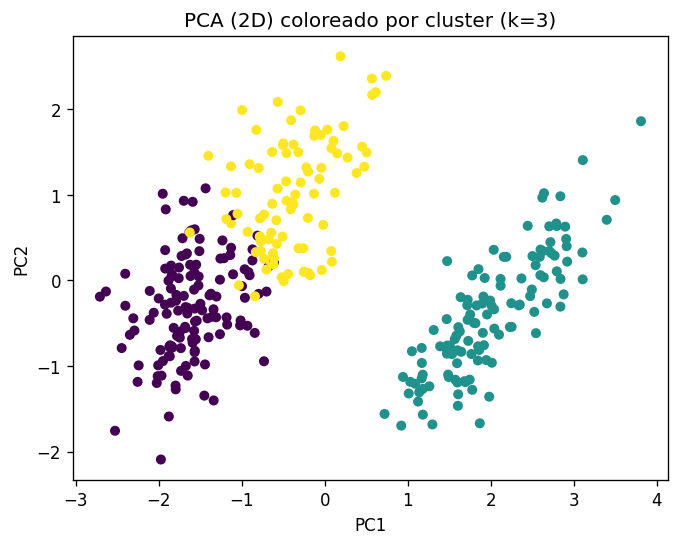

In [19]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, s=25)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA (2D) coloreado por cluster (k={k_final})")
plt.show()


## 6) “Predicción” de especie para datos nuevos

Como K-Means no es supervisado, haremos un mapeo **post-hoc**:

1. Para cada cluster, buscamos la **especie mayoritaria** observada en el dataset (`cluster_to_species`).
2. Para datos nuevos:
   - Preprocesamos con el mismo pipeline,
   - Asignamos cluster con `kmeans_final.predict`,
   - Devolvemos especie estimada y una distribución empírica `p_especie` según el cluster.

Esto sirve como baseline. Para clasificación real, preferir un modelo supervisado.


In [20]:
# Mapeo cluster -> especie por mayoría
cluster_to_species = (
    work.groupby("cluster")[target_col]
        .agg(lambda s: s.value_counts().idxmax())
        .to_dict()
)
print("Mapeo cluster -> especie (mayoría):")
cluster_to_species


Mapeo cluster -> especie (mayoría):


{0: 'Adelie', 1: 'Gentoo', 2: 'Chinstrap'}

In [21]:
# Distribución empírica de especies por cluster (para pseudo-probabilidades)
cluster_species_dist = (
    work.groupby("cluster")[target_col]
        .value_counts(normalize=True)
        .rename("p")
        .reset_index()
)

dist_dict = {}
for _, row in cluster_species_dist.iterrows():
    dist_dict.setdefault(int(row["cluster"]), {})[row[target_col]] = float(row["p"])

cluster_species_dist.sort_values(["cluster", "p"], ascending=[True, False]).head(10)


,cluster,species,p
0,0,Adelie,0.962121
1,0,Chinstrap,0.037879
2,1,Gentoo,1.000000
3,2,Chinstrap,0.707865
4,2,Adelie,0.280899
5,2,Gentoo,0.011236


In [22]:
def predict_species_new(new_samples: pd.DataFrame) -> pd.DataFrame:
    """
    new_samples: DataFrame con columnas feature_cols.
    Retorna: cluster, especie_predicha (mayoría) y probs empíricas por especie.
    """
    missing = [c for c in feature_cols if c not in new_samples.columns]
    if missing:
        raise ValueError(f"Faltan columnas en new_samples: {missing}")

    X_new = preprocess.transform(new_samples[feature_cols])
    cl_new = kmeans_final.predict(X_new)

    species_levels = sorted(work[target_col].dropna().unique())

    rows = []
    for cl in cl_new:
        cl = int(cl)
        probs = dist_dict.get(cl, {})
        rows.append({
            "cluster": cl,
            "species_pred": cluster_to_species.get(cl, "unknown"),
            **{f"p_{sp}": probs.get(sp, 0.0) for sp in species_levels}
        })

    return pd.concat([new_samples.reset_index(drop=True), pd.DataFrame(rows)], axis=1)

# Ejemplo con 3 pingüinos hipotéticos (datos nuevos)
new_data = pd.DataFrame({
    "bill_length_mm": [39.1, 48.7, 44.5],
    "bill_depth_mm": [18.7, 14.1, 17.2],
    "flipper_length_mm": [181, 214, 200],
    "body_mass_g": [3750, 5200, 4200]
})

preds = predict_species_new(new_data)
preds


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,cluster,species_pred,p_Adelie,p_Chinstrap,p_Gentoo
0,39.1,18.7,181,3750,0,Adelie,0.962121,0.037879,0.000000
1,48.7,14.1,214,5200,1,Gentoo,0.000000,0.000000,1.000000
2,44.5,17.2,200,4200,2,Chinstrap,0.280899,0.707865,0.011236


## 7) Interpretación

- Si `k` sale cercano a 3, suele alinearse con la idea de 3 especies principales en el dataset (aunque los clusters no siempre coinciden 1:1 con especie).
- Un **silhouette** más alto sugiere clusters más “compactos y separados”.
- Si la tabla cruzada `cluster vs species` muestra mezclas fuertes, significa que con estas variables no hay separación perfecta por especie (esperable en datos reales).
